In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots

# Dane

Dane są kluczowym elementem projektu. W ramach analiz wykorzystywane są trzy główne typy danych:

- **Skład indeksu S&P 500** – portfele będą tworzone ze spółek wchodzących w skład tego indeksu.
- **Ceny akcji** – niezbędne do symulacji Monte Carlo oraz do narzędzi analizy technicznej.
- **Dane techniczne** – wskaźniki wyliczane na podstawie historycznych cen, używane w strategiach opartych na analizie technicznej.
<!-- - **Dane fundamentalne spółek** – obejmujące wybrane wskaźniki finansowe oraz informacje ze sprawozdań finansowych (Rachunek zysków i strat, Bilans oraz Rachunek przepływów pieniężnych), używane w analizie fundamentalnej. -->

## Wymagania względem danych

1. Wszystkie dane muszą mieć charakter **historyczny**, aby możliwe było poprawne testowanie strategii i modeli w oparciu o warunki rynkowe z przeszłości. Oznacza to, że dane powinny odzwierciedlać stan wiedzy w danym momencie historycznym. Pozwala to uniknąć tzw. **błędu wyprzedzania** informacji (look-ahead bias), który polega na wykorzystaniu w teście danych niedostępnych w momencie podejmowania decyzji, w tym kontekście decyzji inwestycyjnych o składzie portfeli.

2. Dane powinny obejmować odpowiednio **długi okres historyczny**, umożliwiający testowanie strategii inwestycyjnych w dłuższej perspektywie, a nie tylko krótkoterminowych ruchów rynkowych. Inwestowanie to nie spekulacja, wspominając ponownie Grahama.

3. Dane muszą obejmować również spółki, które wypadły z indeksu, lub **spółki, które już nie istnieją**, czyli takie, w których wystąpiła jedna z poniższych sytuacji:
    - bankructwo
    - fuzja lub przejęcie (spółka została wchłonięta przez inną)
    - delisting / wycofanie z giełdy (np. zmiana statusu prywatnego lub restrukturyzacja)
Jest to konieczne, aby uniknąć **błędu przeżywalności** (survivorship bias), czyli sytuacji, w której uwzględnia się wyłącznie spółki przetrwałe. Błąd przeżywalności i błąd wyprzedzania w praktyce mają podobny efekt – w backtestingu modele lub strategie dysponują informacjami o przyszłości, które w rzeczywistości nie były dostępne w danym momencie. Skutkuje to zawyżeniem stóp zwrotu i efektywności strategii, prowadząc do mylnych wniosków o ich skuteczności.

    Poniższa mapa cieplna przedstawia komponenty indeksu S&P 500 z ich 10-letnimi stopami zwrotu. Średnia ważona stopa zwrotu tych spółek jest znacznie wyższa niż 10-letnia stopa zwrotu samego indeksu, którego skład zmieniał się w tym czasie. Ten przykład doskonale ilustruje, jak błąd przeżywalności może nierealistycznie zawyżyć wyniki.

    ![S&P 500 ETF Components' 10-year returns (2026.03.24)](images/6-sp500-etf-components-10y-returns.png)
Źródło: [MarketScreener - S&P 500 ETF Components](https://www.marketscreener.com/quote/index/S-P-500-4985/heatmap/)

4. Dane muszą być **skorygowane o splity akcji** (podział akcji zwiększający ich liczbę w obrocie) oraz o **dywidendy** (część zysku przedsiębiorstwa wypłacana akcjonariuszom).

5. Dane cenowe powinny mieć **spójną częstotliwość** (np. dzienne EOD, tygodniowe, miesięczne), aby umożliwić porównywalne analizy.

6. Dane powinny być **wysokiej jakości** - wolne od błędów, braków oraz duplikatów.

## Dane o składzie indeksu

Do pozyskania danych o składzie indeksu S&P 500 przydatny jest projekt projekt [fja05680/sp500](https://github.com/fja05680/sp500/tree/1bfcb10f2743108de671021ea78217ab07bab2ad) na GitHub. Zawiera on zarówno aktualną, jak i historyczną listę spółek wchodzących w skład indeksu oraz przykładowe notebooki umożliwiające pobranie tych danych. Projekt jest regularnie aktualizowany, co zapewnia dostęp do aktualnych informacji o składzie indeksu. Jednakże, jak sam autor podkreśla, nie ma gwarancji, iż wszystkie dane są w 100% prawidłowe.

### Dane o aktualnym składzie indeksu

Aktualny skład indeksu jest pozyskiwany z [Wikipedii](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies).

In [3]:
dataset.SP500.generate_current(cleanup_old=True)

/home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Executing: 100%|██████████| 6/6 [00:09<00:00,  1.53s/cell]

Generated new file: sp500_2026-04-14.csv
Deleted old file: sp500_2026-04-13.csv
Deleted 1 old file(s) matching pattern: sp500_????-??-??.csv


PosixPath('/home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/external/sp500/sp500_2026-04-14.csv')

In [4]:
plots.summarize_df(dataset.SP500.load_current())

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Symbol                 503 non-null    str  
 1   Security               503 non-null    str  
 2   GICS Sector            503 non-null    str  
 3   GICS Sub-Industry      503 non-null    str  
 4   Headquarters Location  503 non-null    str  
 5   Date added             503 non-null    str  
 6   CIK                    503 non-null    int64
 7   Founded                503 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.6 KB
None


,CIK
count,503.00000000
mean,852457.25447316
std,578782.78221774
min,1800.00000000
25%,106287.50000000
50%,912595.00000000
75%,1284742.00000000
max,2058873.00000000


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927
502,ZTS,Zoetis,Health Care,Pharmaceuticals,"Parsippany, New Jersey",2013-06-21,1555280,1952


### Dane o historycznym składzie indeksu

Historyczny skład indeksu jest budowany na podstawie pliku S&P 500 Historical Components & Changes, udostępnionego wraz z książką [Trading Evolved](https://books.google.pl/books/about/Trading_Evolved.html?id=xSc0yQEACAAJ&source=kp_book_description&redir_esc=y) autorstwa Andreas Clenow, który obejmuje okres 1996–2019. Następnie dane są ręcznie aktualizowane o zmiany po 2019 roku na podstawie informacji z Wikipedia oraz dodatkowych źródeł internetowych, ponieważ sekcja „Selected Changes” nie zawiera pełnej historii modyfikacji indeksu. Końcowy zbiór danych powstaje poprzez scalenie oryginalnego pliku z późniejszymi zmianami oraz wykonanie podstawowego czyszczenia danych, co pozwala uzyskać aktualny plik obejmujący pełną historię zmian składu indeksu.

In [5]:
dataset.SP500.generate_historical(cleanup_old=True)

Executing: 100%|██████████| 19/19 [00:02<00:00,  8.87cell/s]

Generated new file: sp500_historical_2026-04-14.csv
Deleted old file: sp500_historical_2026-04-13.csv
Deleted 1 old file(s) matching pattern: sp500_historical_????-??-??.csv


PosixPath('/home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/external/sp500/sp500_historical_2026-04-14.csv')

In [6]:
sp500_components = dataset.SP500.load_historical()
plots.summarize_df(sp500_components)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 2705 entries, 0 to 2704
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   date     2705 non-null   str  
 1   tickers  2705 non-null   str  
dtypes: str(2)
memory usage: 42.4 KB
None


,date,tickers
count,2705,2705
unique,2705,679
top,1996-01-02,"A,AABA,AAPL,ABC,ABI,ABKFQ,ABS,ABT,ACV,ADBE,ADC..."
freq,1,23


,date,tickers
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
2703,2025-12-22,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2704,2026-01-14,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."


Na podstawie poniższego wykresu przedstawiającego liczbę spółek wchodzących do indeksu na początku każdego roku widać, że mimo nazwy „S&P 500” liczba komponentów nie zawsze wynosi dokładnie 500.

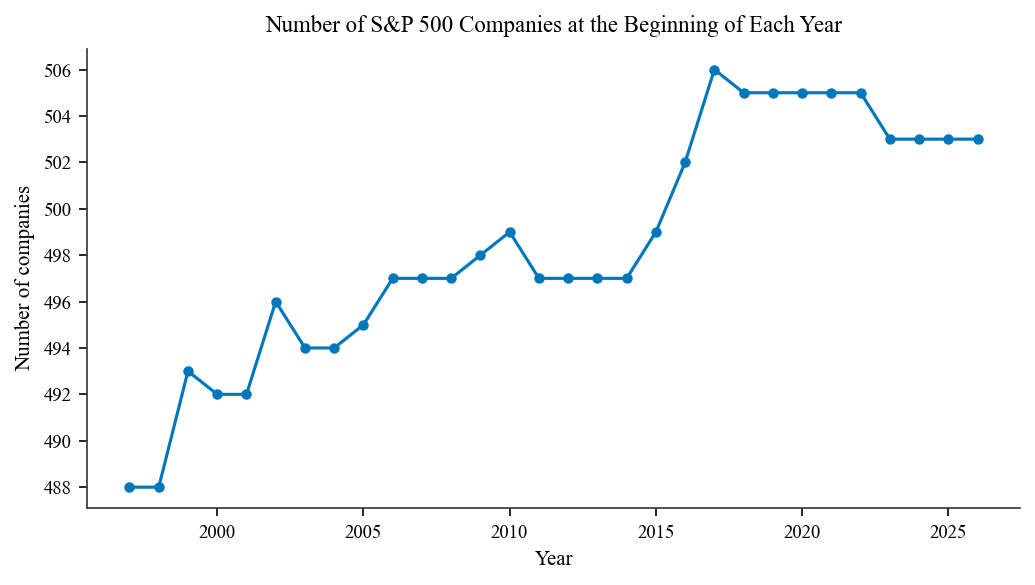

,Year,NumCompanies
0,1997,488.00000000
1,1998,488.00000000
2,1999,493.00000000
3,2000,492.00000000
4,2001,492.00000000
5,2002,496.00000000
6,2003,494.00000000
7,2004,494.00000000
8,2005,495.00000000
9,2006,497.00000000


In [7]:
plots.SP500.companies_per_year_start(sp500_components)

Na przestrzeni ostatnich 30 lat można zauważyć spadek rotacji w indeksie w porównaniu z okresem bańki internetowej w 2000 roku oraz latami poprzedzającymi kryzys 2008 roku, a w ciągu ostatnich 15 lat rotacja ustabilizowała się na poziomie około 20 spółek rocznie. Zmiany w składzie indeksu oraz częstotliwość selekcji będą miały wpływ na skład tworzonych portfeli.

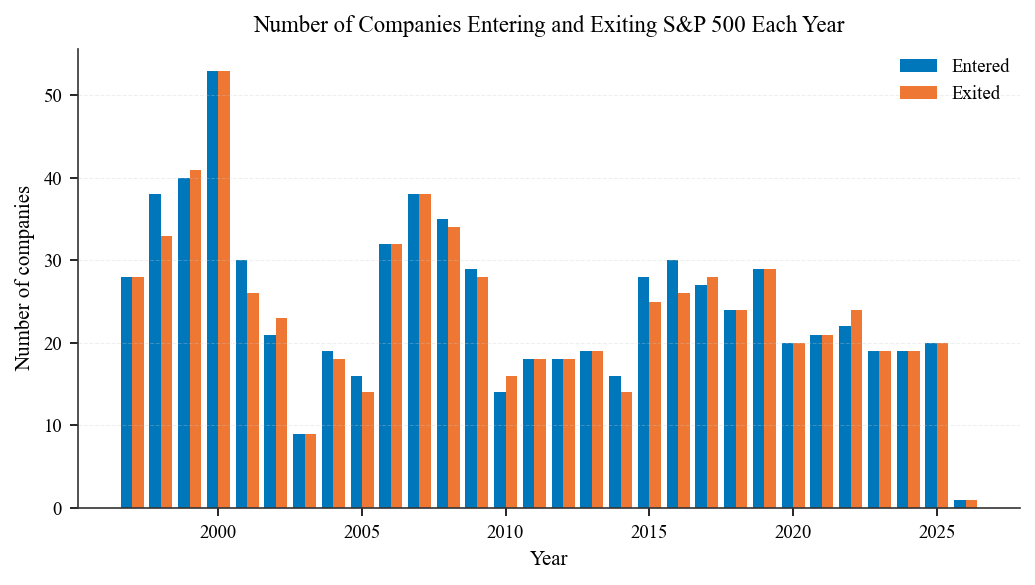

,Year,Entered,Exited
0,1997,28,28
1,1998,38,33
2,1999,40,41
3,2000,53,53
4,2001,30,26
5,2002,21,23
6,2003,9,9
7,2004,19,18
8,2005,16,14
9,2006,32,32


In [8]:
plots.SP500.yearly_changes(sp500_components)

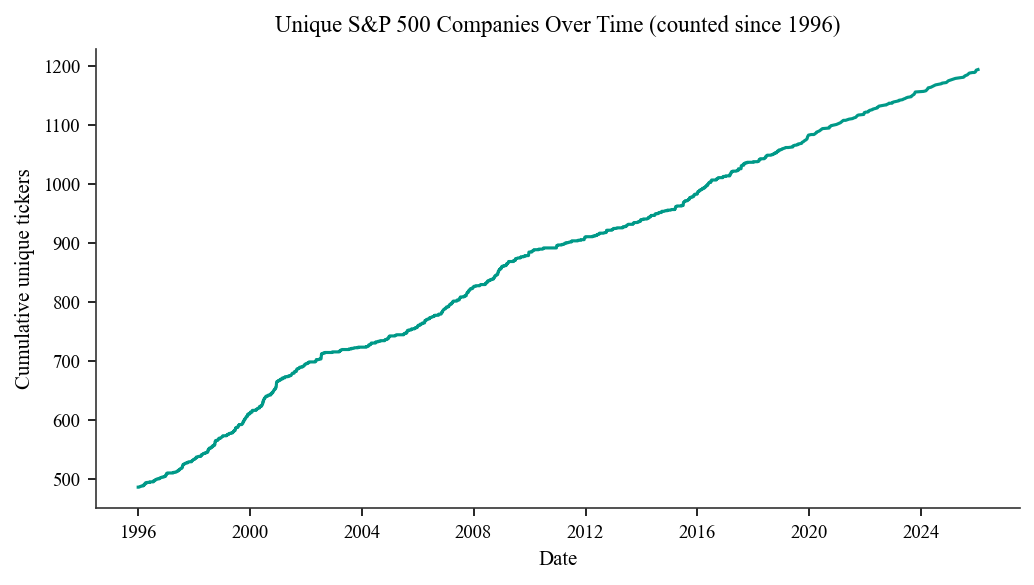

1194 unique companies were listed in the S&P 500 over the period 1996-01-02 → 2026-01-14 (30 years, 0 months)


,date,tickers,unique_cum
0,1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
1,1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
2,1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
3,1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
4,1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD...",487
...,...,...,...
2700,2025-11-11,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1189
2701,2025-11-28,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1189
2702,2025-12-11,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1190
2703,2025-12-22,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP...",1193


In [9]:
plots.SP500.count_unique_companies(sp500_components)